# Risultati, statistiche e performance di ItalianClassification
<!-- ## Training Dataset
Il dataset in input è composto da 2 input_file diversi, uno proveniente dagli output di RedPajama (caratterizzante quasi la totalità dei testi) ed uno composto da 500 test etichettati manualmente dal team di progetto.
Total Documents = 11582
A seguito del filtraggio secondo la lingua italiana attraverso LanguageFilter, 
Total Documents = 10139
Good = 2316 (22.8%)
Bad = 7823 (77.2%)

Durante il training si è scelto un validation set pari al 20% del dataset in input, composto quindi da:
bad: 1537
good: 452
total: 1989 -->





In [ ]:
import joblib 
import lightgbm as lgb
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
)
import pandas as pd


artifact = joblib.load("../models/lgbm_quality_model.joblib")
model : lgb.LGBMClassifier = artifact["model"] 
scaler : StandardScaler = artifact["scaler"]

csv_path = "../output/feature/doc_stats_per_file.csv"
feature_names = [
"language_score",
"length",
"white_space_ratio",
"non_alpha_digit_ratio",
"digit_ratio",
"uppercase_ratio",
"elipsis_ratio",
"punctuation_ratio",
"word_count",
"sentence_count",
"vocabulary_size",
"lowercase_ratio",
"vowel_ratio",
"consonant_ratio",
"avg_word_length",
"avg_sentence_length", # molto importante per capire la scorrevolezza di un testo
"quote_ratio",
"parenthesis_ratio",
"comma_ratio",
"period_ratio",
"question_mark_ratio",
"exclamation_ratio",
"colon_ratio",
"semicolon_ratio",
"stopword_ratio", # può aiutare ma può anche creare bias (importante per capire la scorrevolezza di un testo)
"line_count",
"paragraph_count",
"avg_line_length",
"avg_paragraph_length",
"empty_line_ratio",
"bullet_point_count",
"bullet_point_ratio",
"url_count",
"url_density",
"email_count",
"email_density",
"html_tag_count",
"html_tag_ratio",
"special_char_ratio",
"most_common_word_freq",    # molto importante per capire la scorrevolezza di un testo
"repeated_word_count",
"repeated_word_ratio",  # molto importante per capire la scorrevolezza di un testo
"repeated_char_count",
"repeated_char_ratio",
"repeated_sequence_count",
"text_entropy", # molto importante per calcolare la qualità del testo
"unique_word_count",
"unique_word_ratio",    # molto importante per capire la scorrevolezza di un testo
"all_caps_word_ratio",
"all_lowercase_word_ratio",
"mixed_case_word_ratio",
"consecutive_spaces_count",
"consecutive_punctuation_count"
]
LABEL_MAP = {"bad": 0, "good": 1}


df = pd.read_csv(csv_path)
# Estraggo feature e label
X = df[feature_names]
y = df["label"].map(LABEL_MAP)

if y.isna().any():
    invalid = df["label"][y.isna()].unique().tolist()
    raise ValueError(
        f"Valori label non validi: {invalid}. Ammessi: 'good', 'bad'."
    )

# Scalo le feature usando lo scaler del modello
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

# Predizioni
y_pred = model.predict(X_scaled)
y_pred_proba = model.predict_proba(X_scaled)[:, 1]  # Probabilità della classe "good"


# Calcolo metriche
accuracy = accuracy_score(y, y_pred)
balanced_acc = balanced_accuracy_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_proba)
f1 = f1_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report_dict = classification_report(
    y, y_pred, target_names=["bad", "good"], output_dict=True
)
report_str = classification_report(
    y, y_pred, target_names=["bad", "good"]
)


print("\n" + "-" * 80)
print("METRICHE PRINCIPALI")
print("-" * 80)
print(f"Accuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")
print(f"F1-Score:          {f1:.4f}")
print(f"ROC-AUC:           {roc_auc:.4f}")

print("\n" + "-" * 80)
print("CLASSIFICATION REPORT (DETTAGLIATO)")
print("-" * 80)
print(report_str)

## Calcolo e visualizzo la permutation importance delle feature utilizzate

In [ ]:

perm = permutation_importance(  # non dipende dagli split degli alberi
    model,
    X_scaled,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values(by="importance_mean", ascending=False)

print("\n" + "=" * 80)
print(importance_df)
print("\n" + "=" * 80)
print("\n" + "-" * 80)
print("TOP 10 FEATURES (Feature Importance)")
print("-" * 80)
for idx, row in importance_df.head(10).iterrows():
    importance_pct = (row["importance_mean"] / importance_df["importance_mean"].sum()) * 100
    bar_length = int(importance_pct / 2)
    bar = "█" * bar_length
    print(f"{row['feature']:30s} {bar:40s} {importance_pct:6.2f}% "
            f"(±{row['importance_std']:.4f})")

print("\n" + "=" * 80)

## Confusion Matrix


In [ ]:
import seaborn as sns

cm_df = pd.DataFrame(
    cm,
    index=["Actual bad", "Actual good"],
    columns=["Predicted bad", "Predicted good"],
)
print("\nConfusion matrix (tabellare):")
display(cm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Correlation Matrix of Features



In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


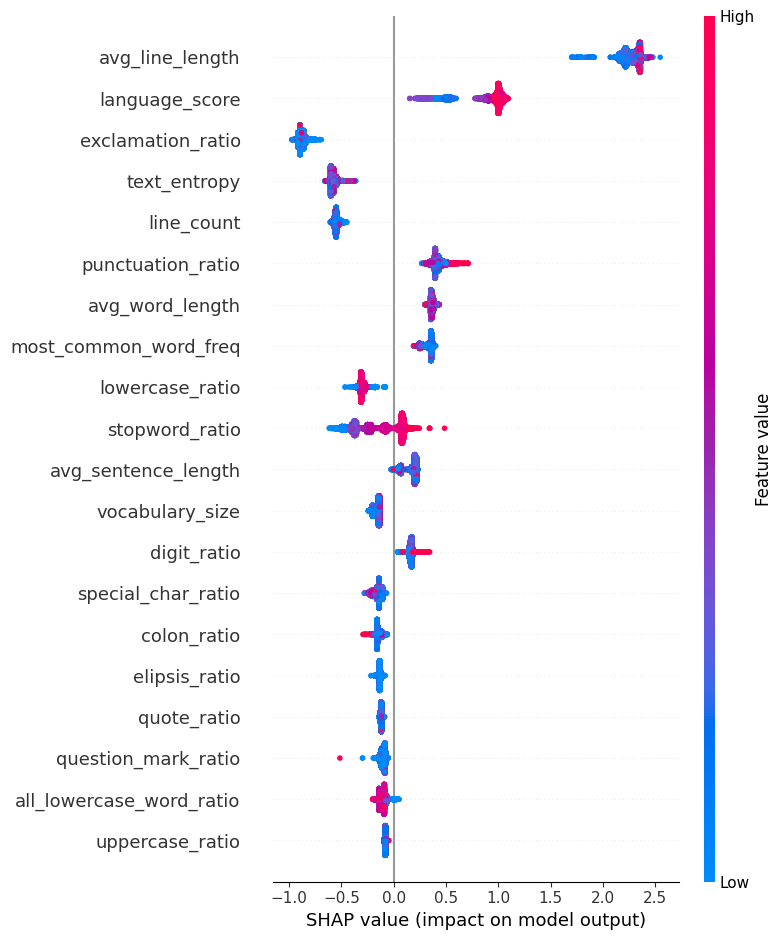

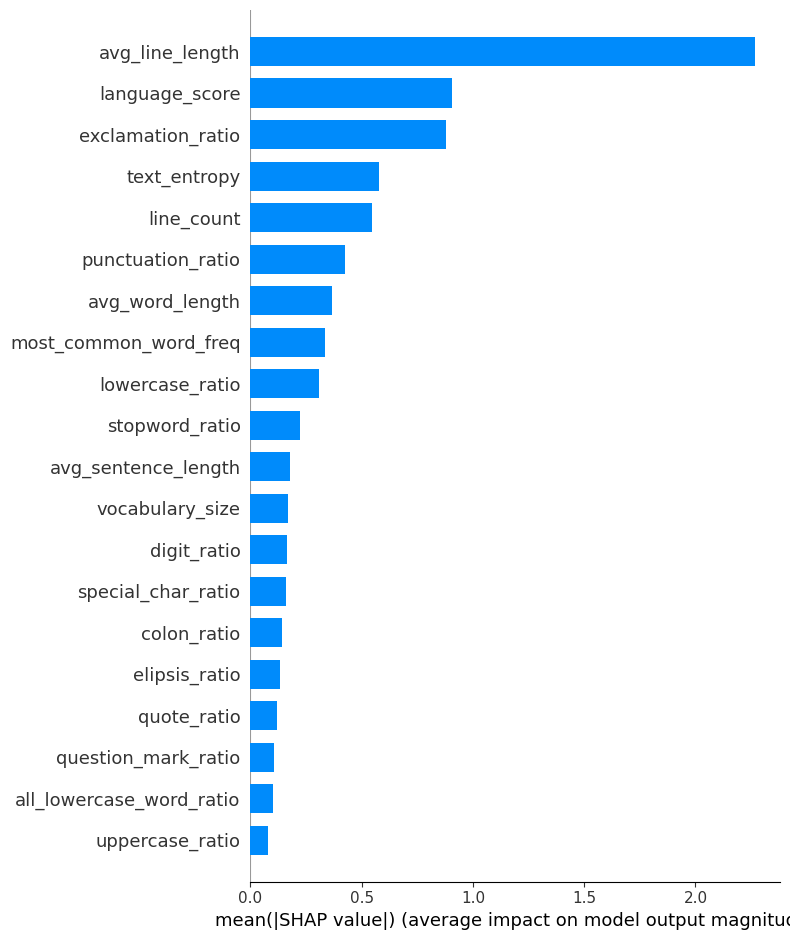

AttributeError: 'str' object has no attribute 'shape'

In [25]:
import shap

# model = tuo modello LGBM già addestrato
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)
shap_values_good = shap_values[1]
shap_values_bad = shap_values[0]

shap.summary_plot(shap_values, X)

shap.summary_plot(shap_values, X, plot_type="bar")

shap.summary_plot("avg_line_lenght", shap_values, X)
